# Sharp regression discontinuity with `pymc` models

In [1]:
import causalpy as cp

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
seed = 42

In [3]:
df = cp.load_data("rd")

## Linear, main-effects, and interaction model

:::{note}
The `random_seed` keyword argument for the PyMC sampler is not necessary. We use it here so that the results are reproducible.
:::

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


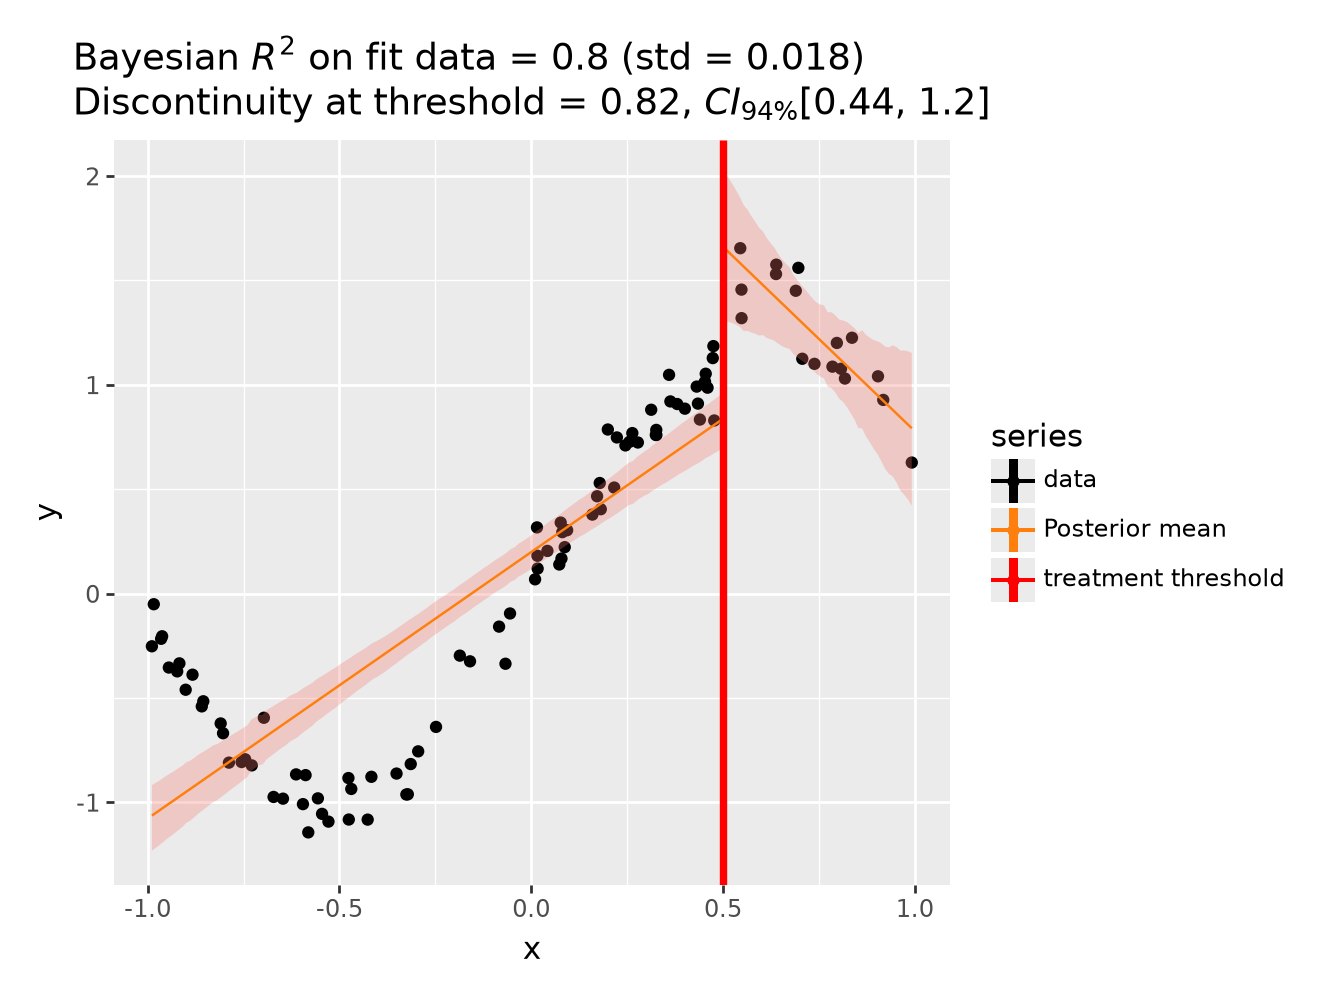

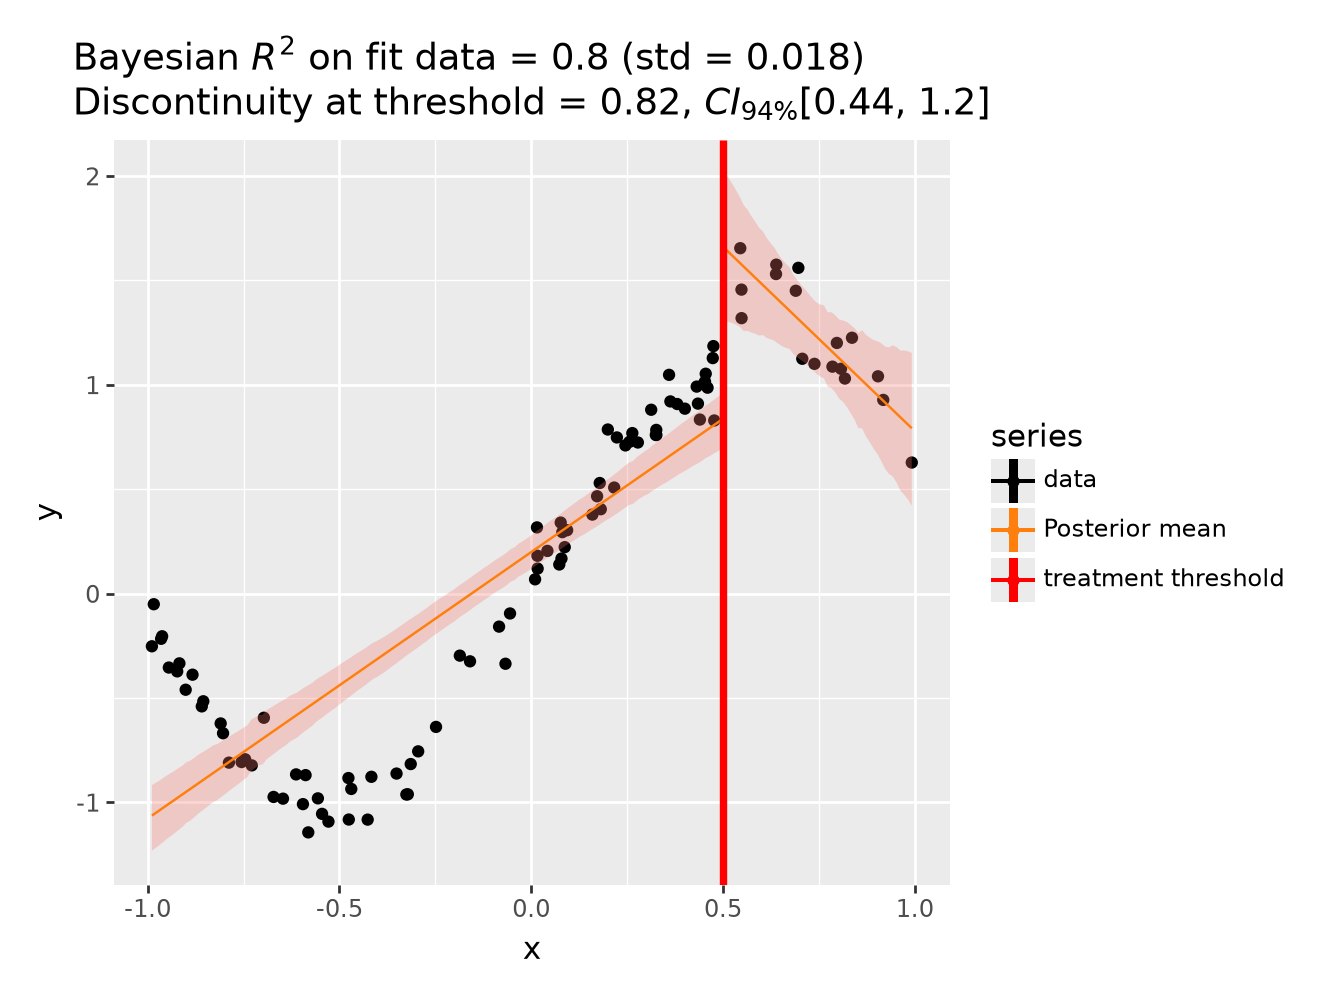

In [4]:
result = cp.RegressionDiscontinuity(
    df,
    formula="y ~ 1 + x + treated + x:treated",
    model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed}),
    treatment_threshold=0.5,
)

fig, ax = result.plot(show=False)
fig

Though we can see that this does not give a good fit of the data almost certainly overestimates the discontinuity at threshold.

## Using a bandwidth

One way how we could deal with this is to use the `bandwidth` kwarg. This will only fit the model to data within a certain bandwidth of the threshold. If $x$ is the running variable, then the model will only be fitted to data where $threshold - bandwidth \le x \le threshold + bandwidth$.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


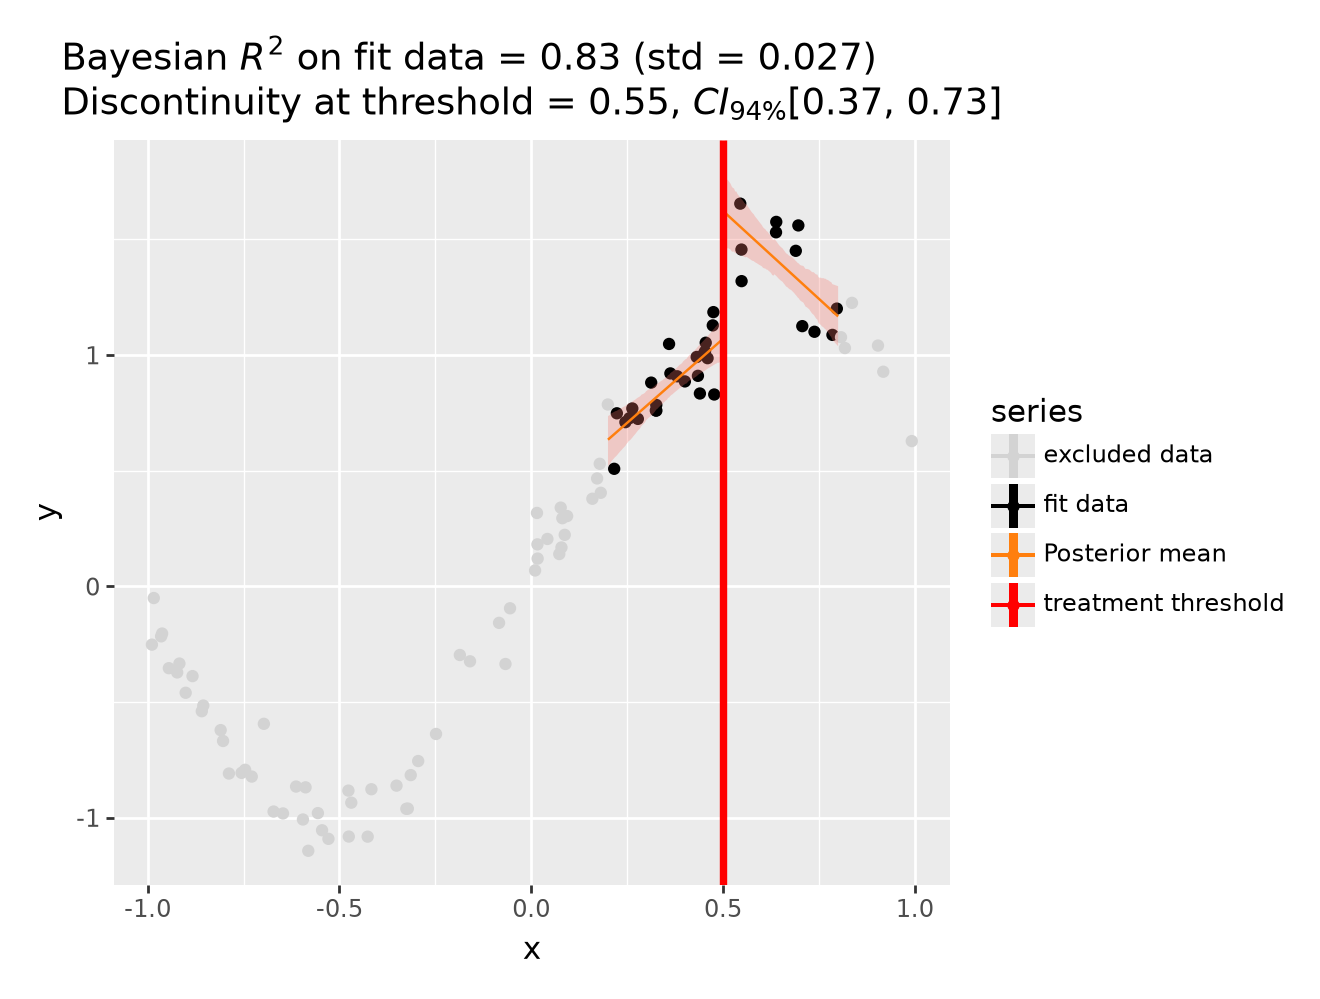

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [5]:
result = cp.RegressionDiscontinuity(
    df,
    formula="y ~ 1 + x + treated + x:treated",
    model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed}),
    treatment_threshold=0.5,
    bandwidth=0.3,
)

result.plot()

We could even go crazy and just fit intercepts for the data close to the threshold. But clearly this will involve more estimation error as we are using less data.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


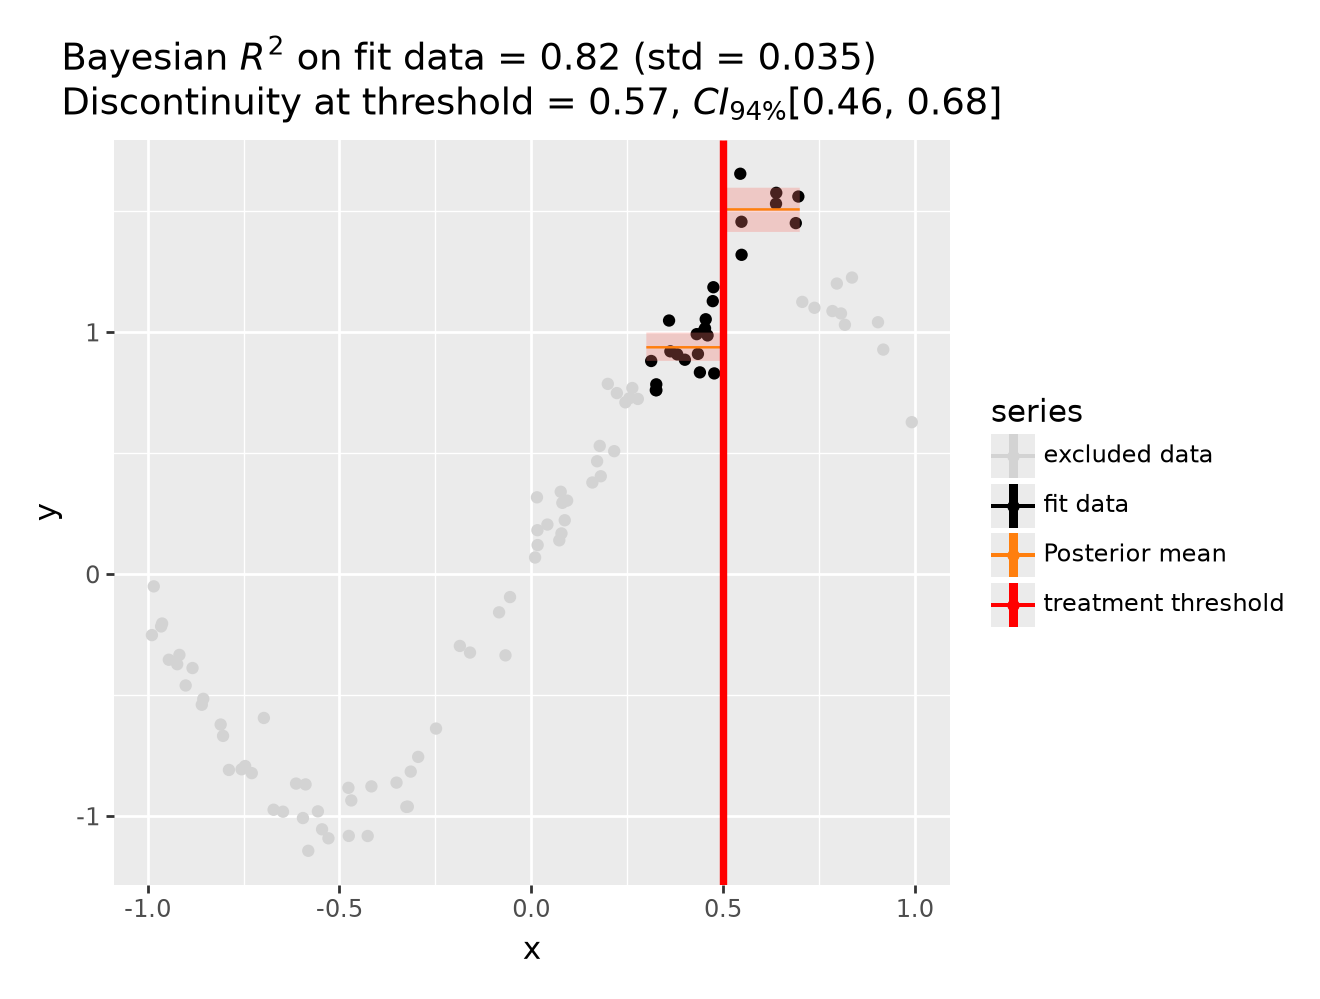

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [6]:
result = cp.RegressionDiscontinuity(
    df,
    formula="y ~ 1 + treated",
    model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed}),
    treatment_threshold=0.5,
    bandwidth=0.2,
)

result.plot()

## Using basis splines

Though it could arguably be better to fit with a more complex model, fit example a spline. This allows us to use all of the data, and (depending on the situation) maybe give a better fit.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


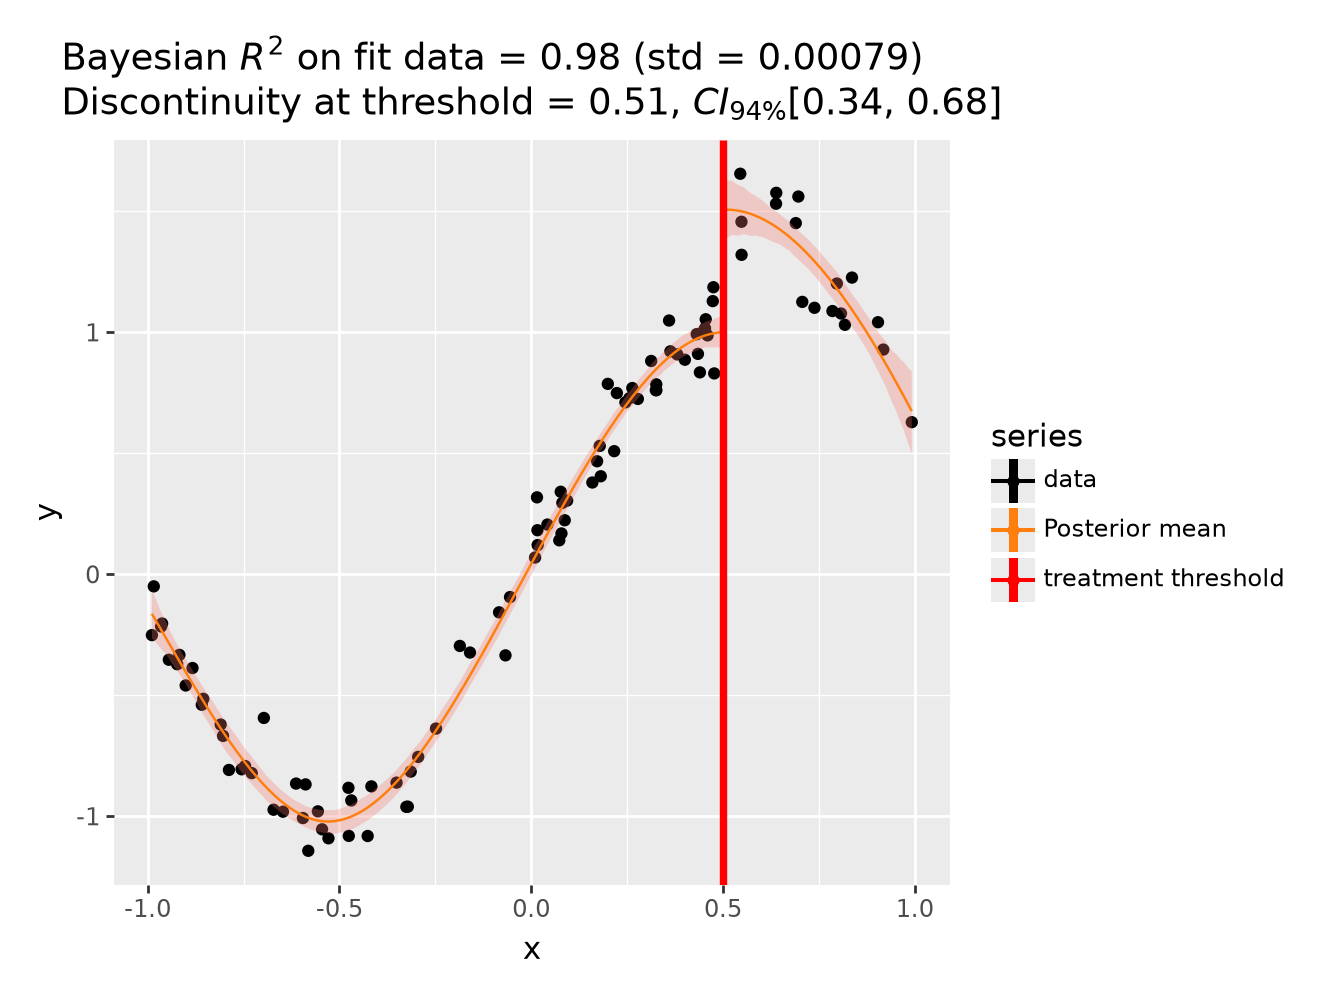

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [7]:
result = cp.RegressionDiscontinuity(
    df,
    formula="y ~ 1 + bs(x, df=6) + treated",
    model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed}),
    treatment_threshold=0.5,
)

result.plot()

As with all of the models in this notebook, we can ask for a summary of the model coefficients.

In [8]:
result.summary()

Regression Discontinuity experiment
Formula: y ~ 1 + bs(x, df=6) + treated
Running variable: x
Threshold on running variable: 0.5
Bandwidth: inf
Donut hole: 0.0
Observations used for fit: 100

Results:
Discontinuity at threshold = 0.51$CI_{94\%}$[0.34, 0.68]


Model coefficients:
    Intercept        -0.16, 94% HDI [-0.26, -0.065]
    treated[T.True]  0.51, 94% HDI [0.34, 0.68]
    bs(x, df=6)[0]   -0.4, 94% HDI [-0.6, -0.2]
    bs(x, df=6)[1]   -1.4, 94% HDI [-1.6, -1.3]
    bs(x, df=6)[2]   0.27, 94% HDI [0.11, 0.43]
    bs(x, df=6)[3]   1.5, 94% HDI [1.4, 1.7]
    bs(x, df=6)[4]   0.89, 94% HDI [0.53, 1.3]
    bs(x, df=6)[5]   0.33, 94% HDI [0.1, 0.55]
    y_hat_sigma      0.11, 94% HDI [0.093, 0.12]


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [9]:
from maketables import ETable

result.set_maketables_options(hdi_prob=0.95)
ETable(result, coef_fmt="b:.3f \n [ci95l:.3f, ci95u:.3f]")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x389a7bb60>

## Effect Summary Reporting

For decision-making, you often need a concise summary of the causal effect. The `effect_summary()` method provides a decision-ready report with key statistics. Note that for Regression Discontinuity, the effect is a single scalar (the discontinuity at the threshold), similar to Difference-in-Differences.


In [10]:
# Generate effect summary
stats = result.effect_summary()
stats.table

,mean,median,hdi_lower,hdi_upper,p_gt_0
discontinuity,0.506269,0.50609,0.332965,0.679456,1.0


In [11]:
print(stats.text)

The discontinuity at threshold was 0.51 (95% HDI [0.33, 0.68]), with a posterior probability of an increase of 1.000.


You can customize the summary with different directions and ROPE thresholds:

- **Direction**: Test for increase, decrease, or two-sided effect
- **Alpha**: Set the HDI confidence level (default 95%)
- **ROPE**: Specify a minimal effect size threshold


In [12]:
# Example: Two-sided test with ROPE
stats = result.effect_summary(
    direction="two-sided",
    alpha=0.05,
    min_effect=0.2,  # Region of Practical Equivalence
)
stats.table

,mean,median,hdi_lower,hdi_upper,p_two_sided,prob_of_effect,p_rope
discontinuity,0.506269,0.50609,0.332965,0.679456,0.0,1.0,1.0


In [13]:
print("\n" + stats.text)


The discontinuity at threshold was 0.51 (95% HDI [0.33, 0.68]), with a posterior probability of an effect of 1.000.
